In [1]:
import numpy as np
import matplotlib.pyplot as plt

Simulation of the stochastic logistic equations, based on "Modelling biological populations in space and time", Eric Renshaw

In [2]:
# Set parameters for logistic equation: X_t=R*X*(1-X/K)
R = 1.0
K  = 50
dimP = K*10 # number of points at which pdf is defined, need to be larger than carrying capacity:

# Corresponding birth-death probability, see lecture notes for the mapping
mu = R/K
lam = R*(1-(1/K))

# Simulate the stochastic logistic equation, using section 3.4
nsteps = 10000
dt = 10**(-3)

# CHANGE 1: added parameters for running many realizations instead of one, and
# for recording the population distribution every 100 steps instead of every step
nreal = 5000
record_every = 100
snapshot_steps = list(range(0, nsteps+1, record_every))   # 0, 100, ..., 10000
dist = np.zeros((len(snapshot_steps), nreal))              # dist[j, i] = population of realization i at snapshot_steps[j]

In [3]:
# CHANGE 2: the whole simulation is now wrapped in a loop over realizations (for i in range(nreal)),
# so it runs nreal times instead of once. N is also given one extra entry (nsteps+1) so there is
# a value at t = nsteps (step 10000). Everything inside the while loop is otherwise unchanged.
for i in range(nreal):
    N = np.zeros(nsteps+1)
    N[0] = 3
    t = 0

    # CHANGE 3: random numbers are pre-drawn (rvals) instead of one np.random.rand(1) call per
    # step. This is purely a speed fix -- calling np.random.rand 5000*10000 times individually
    # is slow. It draws the same kind of random numbers, just all at once. The birth/death
    # comparisons below are identical to the original code.
    rvals = np.random.rand(nsteps)

    # Think about what happens if dt is too large, and why?
    while t < nsteps and N[t] > 0:
        r = rvals[t]
        if r < lam*N[t]*dt:
            N[t+1] = N[t]+1
        elif r < (lam*N[t] + mu*N[t]*(N[t]-1))*dt:
            N[t+1] = N[t]-1
        else:
            N[t+1] = N[t]
        t = t+1

    # CHANGE 4: new block (had no equivalent in the original) -- after this realization's
    # trajectory is complete, record its population at each of the recorded snapshot times
    for j, tstep in enumerate(snapshot_steps):
        dist[j, i] = N[tstep]

In [4]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.default'] = 'regular'
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

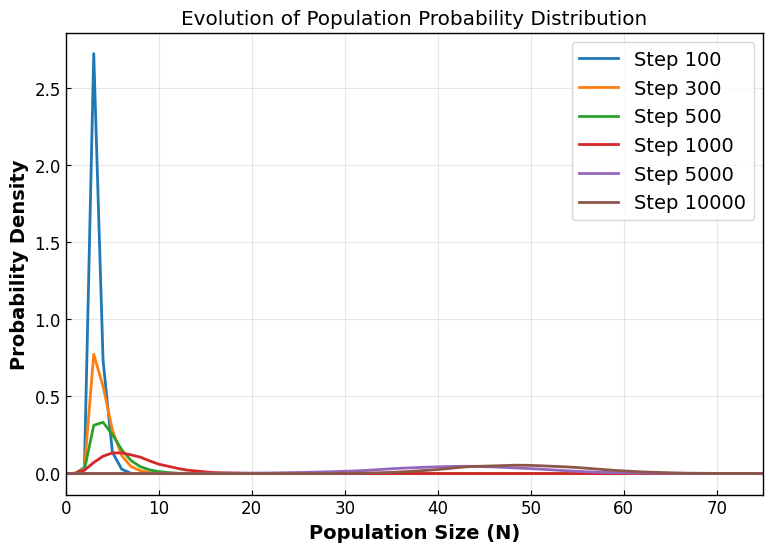

In [5]:
from scipy.stats import gaussian_kde

overlay_steps = [100, 300, 500, 1000, 5000, 10000]
x_grid = np.linspace(0, dimP, 500)

fig, ax = plt.subplots(figsize=(9, 6))
for tstep in overlay_steps:
    j = snapshot_steps.index(tstep)
    data = dist[j, :]
    kde = gaussian_kde(data)
    ax.plot(x_grid, kde(x_grid), linewidth=2, label='Step %d' % tstep)

ax.set_xlim(0, 75)
ax.set_xlabel('Population Size (N)')
ax.set_ylabel('Probability Density')
ax.set_title('Evolution of Population Probability Distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

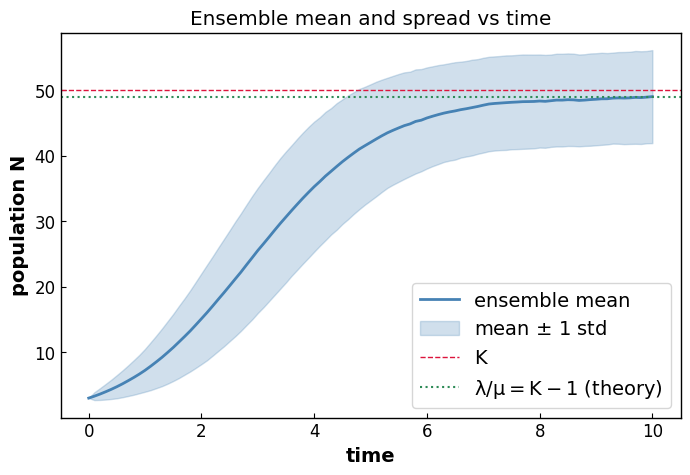

In [6]:
times = np.array(snapshot_steps) * dt
means = dist.mean(axis=1)
stds  = dist.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(times, means, color='steelblue', linewidth=2, label='ensemble mean')
ax.fill_between(times, means-stds, means+stds, color='steelblue', alpha=0.25, label=r'mean $\pm$ 1 std')
ax.axhline(K, color='crimson', linestyle='--', linewidth=1, label='K')
ax.axhline(lam/mu, color='seagreen', linestyle=':', linewidth=1.5, label=r'$\lambda/\mu = K-1$ (theory)')
ax.set_xlabel('time')
ax.set_ylabel('population N')
ax.set_title('Ensemble mean and spread vs time')
ax.legend()
plt.show()

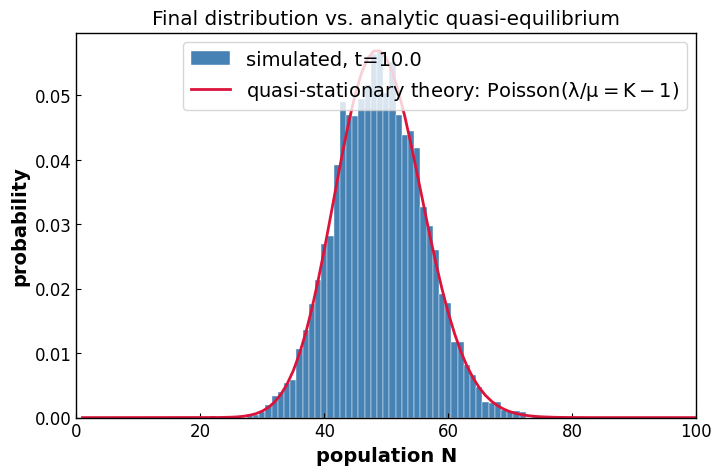

In [ ]:
bins = np.arange(-0.5, dimP+1.5, 1)  # needed here now that the Plot 1 histogram-grid cell (which used to define this) is removed

from scipy.stats import poisson

final = dist[-1, :]
final_nonzero = final[final > 0]

n_vals = np.arange(1, dimP)
poisson_pmf = poisson.pmf(n_vals, mu=lam/mu)
poisson_pmf /= poisson_pmf.sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(final_nonzero, bins=bins, density=True, color='steelblue', edgecolor='white',
        linewidth=0.3, label='simulated, t=%.1f' % (snapshot_steps[-1]*dt))
ax.plot(n_vals, poisson_pmf, color='crimson', linewidth=2,
        label=r'quasi-stationary theory: Poisson($\lambda/\mu = K-1$)')
ax.set_xlim(0, 100)
ax.set_xlabel('population N')
ax.set_ylabel('probability')
ax.set_title('Final distribution vs. analytic quasi-equilibrium')
ax.legend()
plt.show()